# Modelo de Identificação de Fraudes


In [1]:
# Importando o pandas

import pandas as pd

In [2]:
# Importando a base

transacoes = pd.read_csv('creditcard.csv')

<a id='modelo'></a>
### Criando um modelo de aprendizado de máquinas para identificar fraude
- Vamos criar um modelo para identificar fraude sem fazer nenhum tratamento nessa base

In [3]:
# Separando X e y

X = transacoes.drop('Class',axis=1)
y = transacoes.Class

**Separando em treino e teste**

In [4]:
# Separando em treino e teste

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)

**Utilizando a árvore de decisão como fizemos anteriormente**

In [5]:
# Importando a árvore de decisão
from sklearn import tree

In [6]:
# Definindo o nosso classificador
clf = tree.DecisionTreeClassifier(random_state=42)

In [7]:
# Fazendo o fit para os dados de treino
clf = clf.fit(X_train, y_train)

In [8]:
# Prevendo os valores
y_pred = clf.predict(X_test)

**Visualizando a matriz de confusão**

In [9]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred)

array([[93786,    39],
       [   40,   122]], dtype=int64)

### Realizando o random undersampling

In [10]:
# Importando o RandomUnderSampler do imblearn

from imblearn.under_sampling import RandomUnderSampler

In [11]:
# Definindo o RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

In [12]:
# Definindo a nova amostra

X_res_RUS, y_res_RUS = rus.fit_resample(X_train, y_train)

**<font color='blue'>Com árvore de decisão**

In [13]:
# Fazendo o fit para os dados de treino já balanceados

clfTree_RUS = tree.DecisionTreeClassifier(random_state=42)

clfTree_RUS = clf.fit(X_res_RUS, y_res_RUS)

In [14]:
# Fazendo a previsão para os dados de teste

y_predTree_RUS = clfTree_RUS.predict(X_test)
y_pred_probaTree_RUS = clfTree_RUS.predict_proba(X_test)[:,1]

In [15]:
# Visualizando a matriz de confusão

confusion_matrix(y_test,y_predTree_RUS)

array([[84484,  9341],
       [   15,   147]], dtype=int64)

**<font color='blue'>Com Regressão Logística**

In [16]:
# Fazendo o fit

from sklearn.linear_model import LogisticRegression

clfLog_RUS = LogisticRegression(random_state=0).fit(X_res_RUS, y_res_RUS)

In [17]:
# Fazendo a previsão

y_predLog_RUS = clfLog_RUS.predict(X_test)
y_pred_probaLog_RUS = clfLog_RUS.predict_proba(X_test)[:,1]

In [18]:
# Visualizando a matriz de confusão

confusion_matrix(y_test,y_predLog_RUS)

array([[89362,  4463],
       [   19,   143]], dtype=int64)

**<font color='blue'>Com Support Vector Machine**

In [19]:
# Fazendo o fit

from sklearn import svm

clfSVC_RUS = svm.SVC(random_state=0, probability=True).fit(X_res_RUS, y_res_RUS)

In [20]:
# Fazendo a previsão

y_predSVC_RUS = clfSVC_RUS.predict(X_test)
y_pred_probaSVC_RUS = clfSVC_RUS.predict_proba(X_test)[:,1]

In [21]:
# Visualizando a matriz de confusão

confusion_matrix(y_test,y_predSVC_RUS)

array([[41756, 52069],
       [   46,   116]], dtype=int64)

**<font color='blue'>Utilizando KNN**

In [22]:
# Fazendo o fit

from sklearn.neighbors import KNeighborsClassifier

clfKNN_RUS = KNeighborsClassifier(n_neighbors=3).fit(X_res_RUS, y_res_RUS)

In [23]:
# Fazendo a previsão

y_predKNN_RUS = clfKNN_RUS.predict(X_test)
y_pred_probaKNN_RUS = clfKNN_RUS.predict_proba(X_test)[:,1]

In [24]:
# Visualizando a matriz de confusão

confusion_matrix(y_test,y_predKNN_RUS)

array([[60332, 33493],
       [   54,   108]], dtype=int64)

**<font color='blue'>Random Forest**

In [25]:
# Fazendo o fit

from sklearn.ensemble import RandomForestClassifier

clfRFC_RUS = RandomForestClassifier(max_depth=2, random_state=0).fit(X_res_RUS, y_res_RUS)

In [26]:
# Fazendo a previsão

y_predRFC_RUS = clfRFC_RUS.predict(X_test)
y_pred_probaRFC_RUS = clfRFC_RUS.predict_proba(X_test)[:,1]

In [27]:
# Visualizando a matriz de confusão

confusion_matrix(y_test,y_predRFC_RUS)

array([[93168,   657],
       [   25,   137]], dtype=int64)

### Comparando os modelos

In [28]:
# Importar o metrics do sklearn

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [29]:
# Visualizando precisão e recall

print(precision_score(y_test,y_predTree_RUS))
print(recall_score(y_test,y_predTree_RUS))
print(precision_score(y_test,y_predLog_RUS))
print(recall_score(y_test,y_predLog_RUS))
print(precision_score(y_test,y_predSVC_RUS))
print(recall_score(y_test,y_predSVC_RUS))
print(precision_score(y_test,y_predKNN_RUS))
print(recall_score(y_test,y_predKNN_RUS))
print(precision_score(y_test,y_predRFC_RUS))
print(recall_score(y_test,y_predRFC_RUS))

0.015493254637436763
0.9074074074074074
0.031046461137646548
0.8827160493827161
0.002222860975376066
0.7160493827160493
0.0032141900538674444
0.6666666666666666
0.172544080604534
0.845679012345679


In [30]:
# Gerando os parâmetros da curva precisão x recall para a base

from sklearn.metrics import precision_recall_curve

precisionTree_RUS, recallTree_RUS, thresholdsTree_RUS = precision_recall_curve(y_test,y_pred_probaTree_RUS)
precisionLog_RUS, recallLog_RUS, thresholdsLog_RUS = precision_recall_curve(y_test,y_pred_probaLog_RUS)
precisionSVC_RUS, recallSVC_RUS, thresholdsSVC_RUS = precision_recall_curve(y_test,y_pred_probaSVC_RUS)
precisionKNN_RUS, recallKNN_RUS, thresholdsKNN_RUS = precision_recall_curve(y_test,y_pred_probaKNN_RUS)
precisionRFC_RUS, recallRFC_RUS, thresholdsRFC_RUS = precision_recall_curve(y_test,y_pred_probaRFC_RUS)

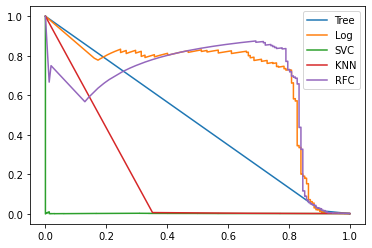

In [31]:
# Visualizando graficamente

import matplotlib.pyplot as plt

# Traçando a curva ROC

fig, ax = plt.subplots()

ax.plot(recallTree_RUS, precisionTree_RUS, label='Tree')
ax.plot(recallLog_RUS, precisionLog_RUS, label='Log')
ax.plot(recallSVC_RUS, precisionSVC_RUS, label='SVC')
ax.plot(recallKNN_RUS, precisionKNN_RUS, label='KNN')
ax.plot(recallRFC_RUS, precisionRFC_RUS, label='RFC')

ax.legend()
plt.show()

In [32]:
# Avaliando a área abaixo da curva de cada um dos casos (Antes da mundança em Times e Amount)

from sklearn import metrics

print(metrics.auc(recallTree_RUS, precisionTree_RUS))
print(metrics.auc(recallLog_RUS, precisionLog_RUS))
print(metrics.auc(recallSVC_RUS, precisionSVC_RUS))
print(metrics.auc(recallKNN_RUS, precisionKNN_RUS))
print(metrics.auc(recallRFC_RUS, precisionRFC_RUS))

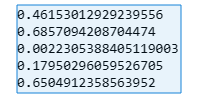

In [33]:
# Avaliando a área abaixo da curva de cada um dos casos (Após a mundança em Times e Amount)

from sklearn import metrics

print(metrics.auc(recallTree_RUS, precisionTree_RUS))
print(metrics.auc(recallLog_RUS, precisionLog_RUS))
print(metrics.auc(recallSVC_RUS, precisionSVC_RUS))
print(metrics.auc(recallKNN_RUS, precisionKNN_RUS))
print(metrics.auc(recallRFC_RUS, precisionRFC_RUS))

0.46153012929239556
0.6857094208704474
0.0022305388405119003
0.17950296059526705
0.6504912358563952


### Ajustando a escala de todas as colunas
- As colunas Time e Amount têm valores max muito alto. Destoa do restante do dataset.

In [34]:
# Verificando o resumo das colunas

transacoes.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,3.918649e-15,5.682686e-16,-8.761736e-15,2.811118e-15,-1.552103e-15,2.040130e-15,-1.698953e-15,-1.893285e-16,-3.147640e-15,...,1.473120e-16,8.042109e-16,5.282512e-16,4.456271e-15,1.426896e-15,1.701640e-15,-3.662252e-16,-1.217809e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Podemos ajustar as colunas Time e Amount para que elas fiquem entre 0 e 1**
- Para isso, vamos dividir toda a coluna pelo valor máximo.

In [35]:
# Primeiro para a coluna Time

transacoes.Time = transacoes.Time / transacoes.Time.max()

In [36]:
# E então para a coluna Amount

transacoes.Amount = transacoes.Amount / transacoes.Amount.max()

**Podemos então [voltar no início da criação do nosso modelo](#modelo) e executar novamente**